In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys
sys.path.append('../analytics')

from sqlalchemy import create_engine
from dotenv import dotenv_values

config = dotenv_values("../server/.env")
engine = create_engine(config["DATABASE_URL"])


plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.facecolor'] = '#0f0f0f'
plt.rcParams['figure.facecolor'] = '#0f0f0f'
plt.rcParams['axes.edgecolor'] = '#333'
plt.rcParams['axes.labelcolor'] = '#999'
plt.rcParams['xtick.color'] = '#666'
plt.rcParams['ytick.color'] = '#666'
plt.rcParams['text.color'] = '#e5e5e5'
plt.rcParams['grid.color'] = '#1a1a1a'
plt.rcParams['grid.linestyle'] = '--'

print("Setup complete")

Setup complete


In [2]:

query = "SELECT * FROM stock_data ORDER BY ticker, date ASC"
df = pd.read_sql(query, engine)
df['date'] = pd.to_datetime(df['date'])

print(f"Total rows: {len(df)}")
print(f"Tickers: {df['ticker'].unique()}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Columns: {list(df.columns)}")

Total rows: 492
Tickers: ['AAPL' 'INFY' 'MSFT' 'TSLA']
Date range: 2025-12-10 → 2026-06-08
Columns: ['ticker', 'date', 'open', 'high', 'low', 'close', 'volume']


In [3]:
print("=== DataFrame Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Basic Statistics ===")
df.groupby('ticker')['close'].describe().round(2)

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 492 entries, 0 to 491
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ticker  492 non-null    object        
 1   date    492 non-null    datetime64[ns]
 2   open    492 non-null    float64       
 3   high    492 non-null    float64       
 4   low     492 non-null    float64       
 5   close   492 non-null    float64       
 6   volume  492 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 27.0+ KB
None

=== Missing Values ===
ticker    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

=== Basic Statistics ===


,count,mean,std,min,25%,50%,75%,max
ticker,,,,,,,,
AAPL,123.0,270.83,17.78,246.24,258.61,267.36,275.69,315.20
INFY,123.0,14.96,2.39,11.66,12.93,14.19,17.78,20.22
MSFT,123.0,422.73,35.70,356.00,399.22,414.22,453.57,485.86
TSLA,123.0,413.78,33.43,343.25,391.58,411.79,435.79,489.88


In [4]:
ticker_counts = df.groupby('ticker').size().reset_index(name='rows')
print(ticker_counts)

  ticker  rows
0   AAPL   123
1   INFY   123
2   MSFT   123
3   TSLA   123


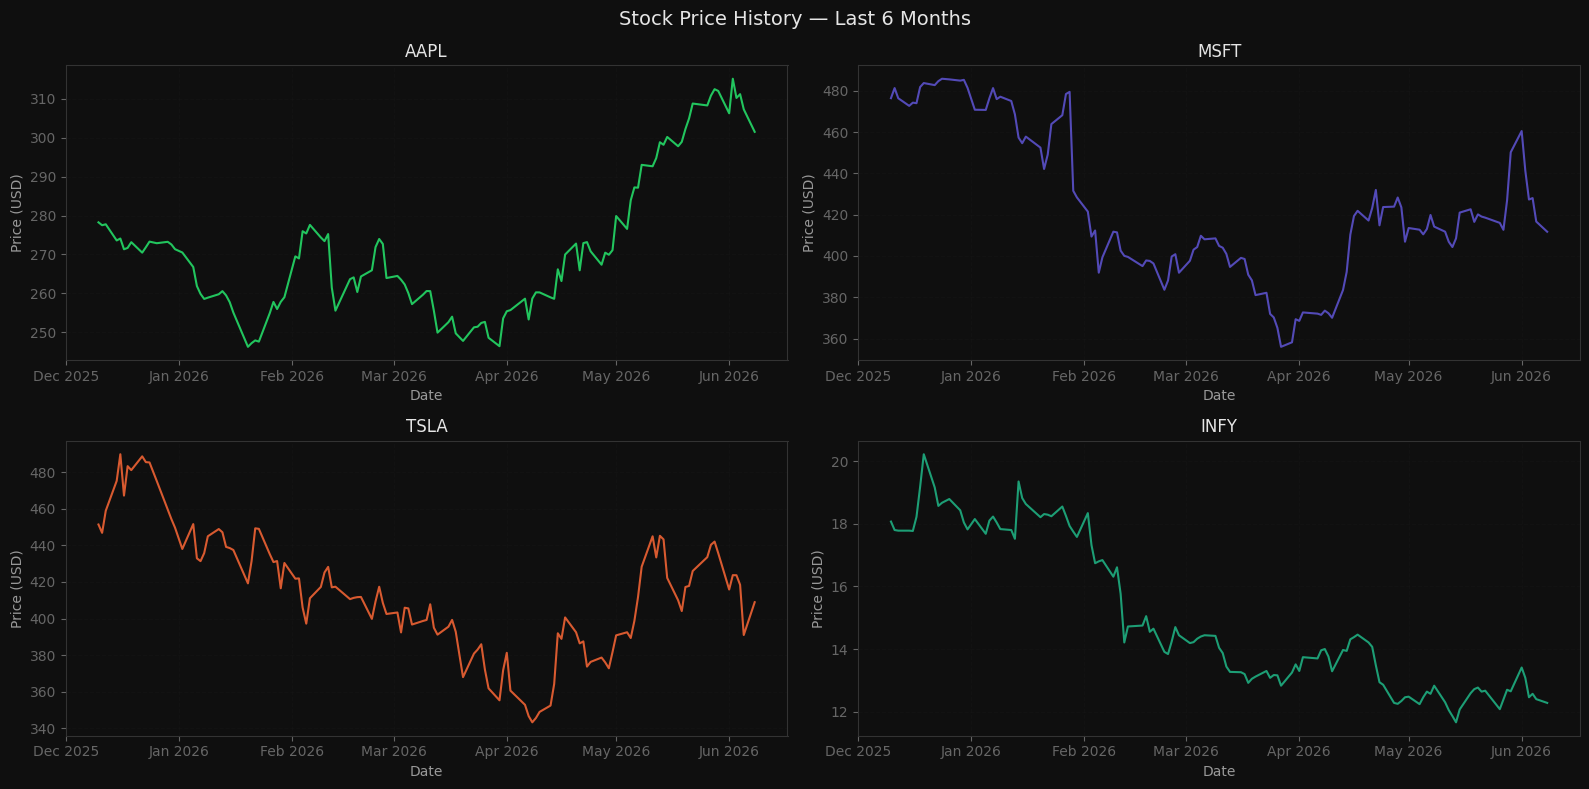

Chart saved as price_history.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Stock Price History — Last 6 Months', fontsize=14, color='#e5e5e5')

tickers = ['AAPL', 'MSFT', 'TSLA', 'INFY']
colors  = ['#22c55e', '#534AB7', '#D85A30', '#1D9E75']

for ax, ticker, color in zip(axes.flatten(), tickers, colors):
    data = df[df['ticker'] == ticker]
    ax.plot(data['date'], data['close'], color=color, linewidth=1.5)
    ax.set_title(ticker, color='#e5e5e5', fontsize=12)
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD)')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('price_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as price_history.png")

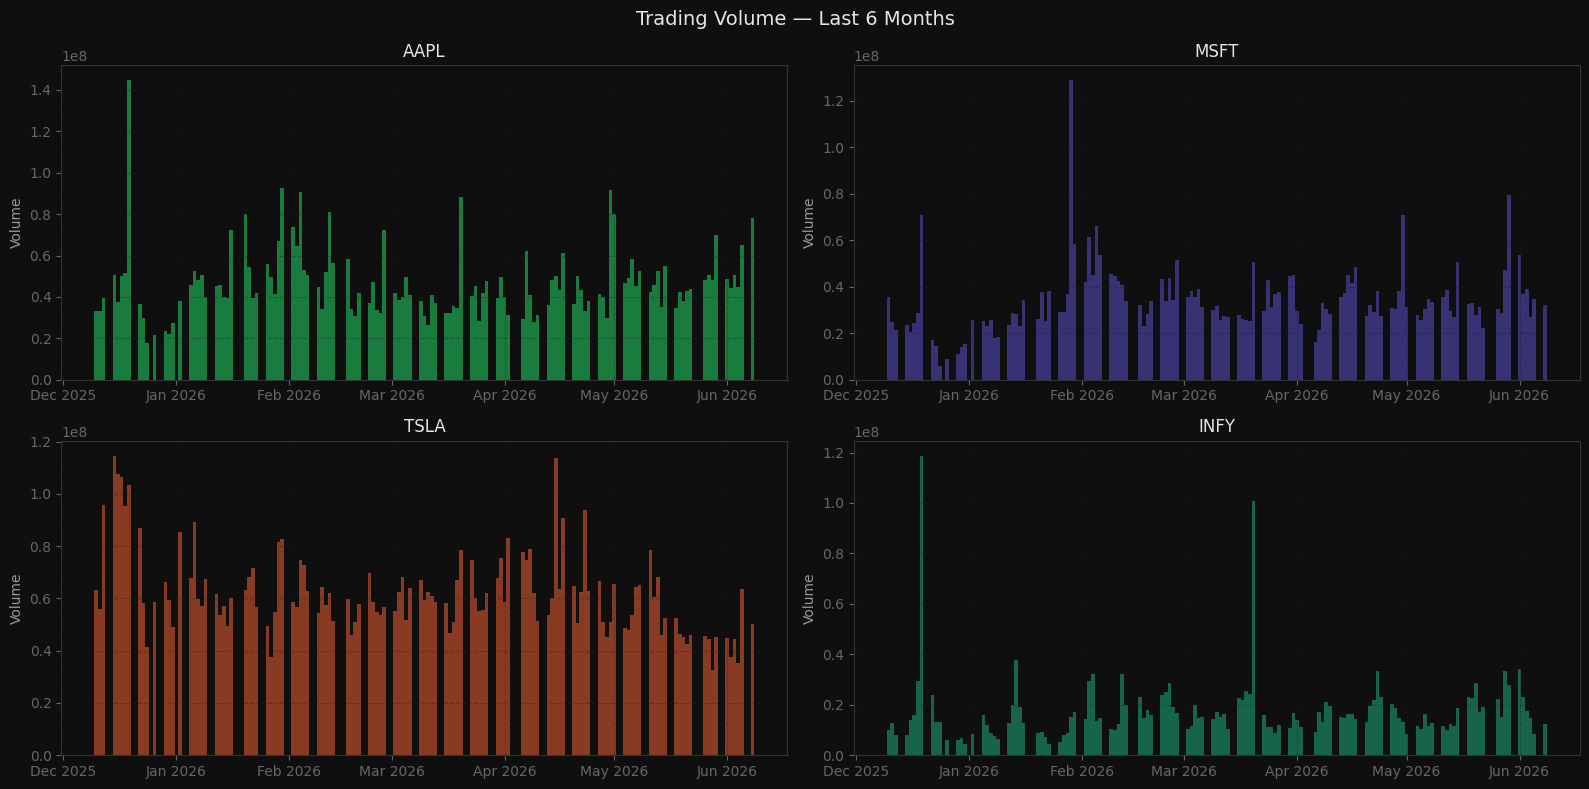

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Trading Volume — Last 6 Months', fontsize=14, color='#e5e5e5')

for ax, ticker, color in zip(axes.flatten(), tickers, colors):
    data = df[df['ticker'] == ticker]
    ax.bar(data['date'], data['volume'], color=color, alpha=0.6, width=1)
    ax.set_title(ticker, color='#e5e5e5', fontsize=12)
    ax.set_ylabel('Volume')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('volume_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

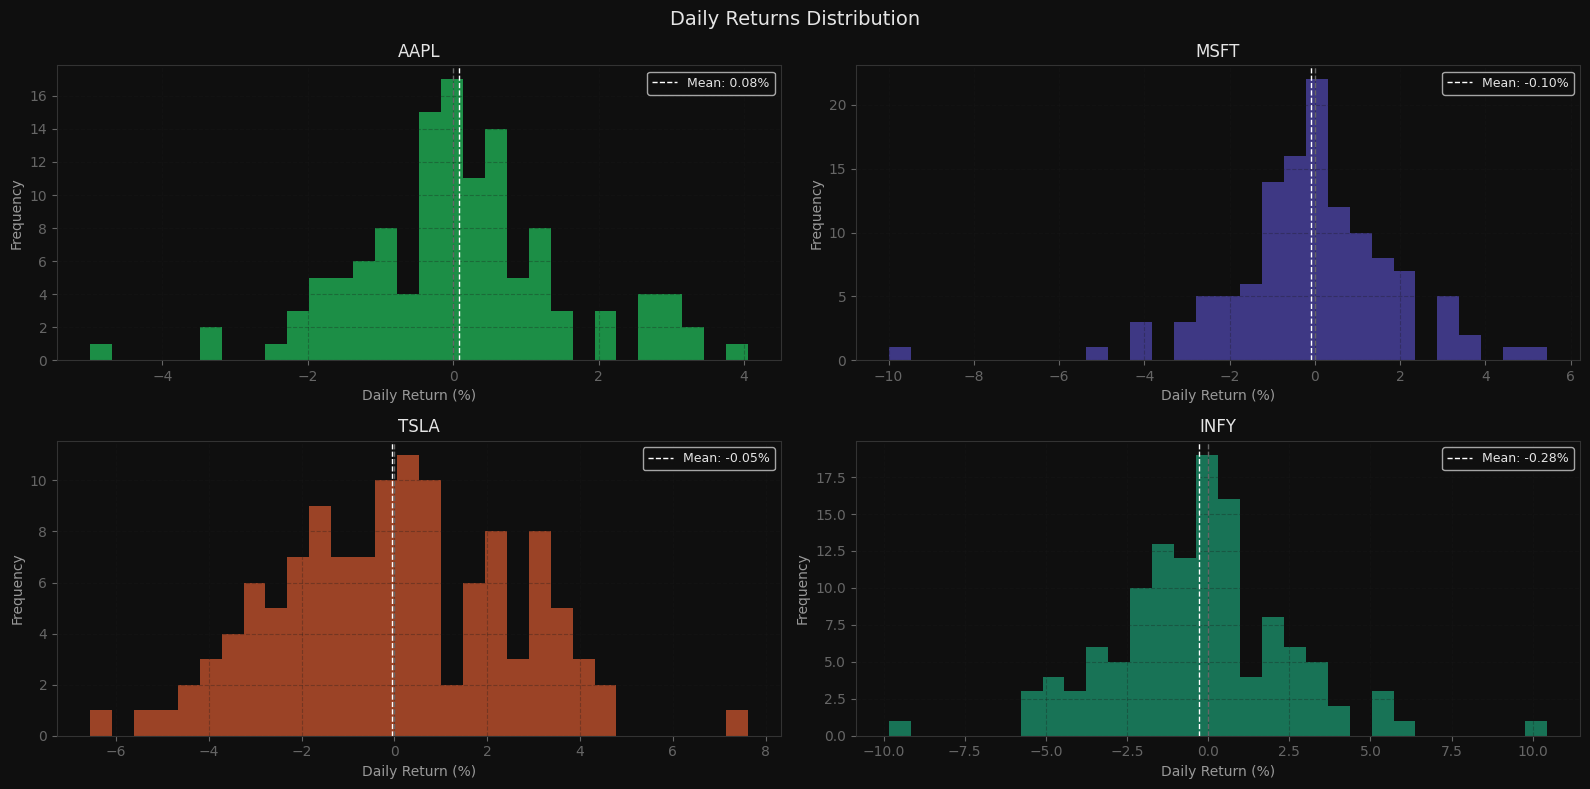

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Daily Returns Distribution', fontsize=14, color='#e5e5e5')

for ax, ticker, color in zip(axes.flatten(), tickers, colors):
    data = df[df['ticker'] == ticker].copy()
    data['daily_return'] = data['close'].pct_change() * 100
    
    ax.hist(data['daily_return'].dropna(), bins=30, color=color, alpha=0.7, edgecolor='none')
    ax.axvline(x=0, color='#666', linestyle='--', linewidth=1)
    ax.set_title(ticker, color='#e5e5e5', fontsize=12)
    ax.set_xlabel('Daily Return (%)')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)
    
    mean_return = data['daily_return'].mean()
    ax.axvline(x=mean_return, color='#fff', linestyle='--', linewidth=1, label=f'Mean: {mean_return:.2f}%')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('returns_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
summary = []
for ticker in tickers:
    data = df[df['ticker'] == ticker].copy()
    data['daily_return'] = data['close'].pct_change()
    
    summary.append({
        'Ticker'          : ticker,
        'Start Price'     : f"${data['close'].iloc[0]:.2f}",
        'End Price'       : f"${data['close'].iloc[-1]:.2f}",
        'Total Return'    : f"{((data['close'].iloc[-1] / data['close'].iloc[0]) - 1) * 100:.2f}%",
        'Max Price'       : f"${data['high'].max():.2f}",
        'Min Price'       : f"${data['low'].min():.2f}",
        'Avg Daily Volume': f"{data['volume'].mean():,.0f}",
        'Avg Daily Return': f"{data['daily_return'].mean() * 100:.3f}%",
        'Volatility'      : f"{data['daily_return'].std() * 100:.3f}%",
    })

summary_df = pd.DataFrame(summary).set_index('Ticker')
print("\n=== Summary Statistics ===")
summary_df


=== Summary Statistics ===


,Start Price,End Price,Total Return,Max Price,Min Price,Avg Daily Volume,Avg Daily Return,Volatility
Ticker,,,,,,,,
AAPL,$278.26,$301.54,8.37%,$317.40,$242.97,"46,904,242",0.076%,1.445%
MSFT,$476.44,$411.74,-13.58%,$487.53,$355.51,"34,190,090",-0.100%,1.981%
TSLA,$451.45,$408.95,-9.41%,$498.83,$337.24,"62,332,889",-0.049%,2.523%
INFY,$18.07,$12.28,-32.04%,$30.00,$11.56,"17,522,320",-0.280%,2.711%
